# Mid-circuit measurement benchmark on Quantinuum Helios: 1D chains

This notebook benchmarks how well Quantinuum's **Helios-1** performs the basic cycle of quantum error
correction - **measure an ancilla mid-circuit, then correct the data qubits based on the outcome** - on
Ising chains of tens of qubits. It builds the programs in Guppy, prices them with Nexus, submits them,
collects the results and turns them into an effective error per edge.

**Safe by default:** nothing is uploaded or sent until you set `SUBMIT = True`. Until then the notebook
runs the very same circuits on a local simulator (Aer), on short chains, so the whole pipeline can be
checked for free. Those results are filed as `Helios-1_sim` and flagged `"simulated": true`.

**Requirements**
* `pip install -e ".[quantinuum]"` from the repository root (Guppy and `qnexus`), or keep the `sys.path`
  line of the next cell;
* for Helios, a Nexus account with access to the machine, logged in once with
  `import qnexus as qnx; qnx.login()`.

In [ ]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))          # not needed after `pip install -e .`
DATA, FIGURES = ROOT / "data", ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np

from qecbench.analysis import load_results
from qecbench.backends import QuantinuumBackend, chain_instances
from qecbench.backends.quantinuum import peak_qubits
from qecbench.experiment import build_plan, harvest, print_plan, submit
from qecbench.noise_study import accumulated_error, fit_lambda_eff, overlap_model

## 0. Background

### The task: linear-ramp QAOA on an Ising chain

Take $n$ data qubits on a line and the Hamiltonian

$$H = \sum_{i=0}^{n-2} Z_i Z_{i+1}, \qquad E(x) = \sum_i z_i z_{i+1},\quad z_i = 1 - 2x_i .$$

Its ground states are the two alternating bitstrings ($E_{\min} = -(n-1)$). The circuit is the
**linear-ramp QAOA**: start in $|+\rangle^{\otimes n}$ and apply $p$ layers of $e^{-i\gamma_k H}$ followed by
$R_X(-2\beta_k)$ on every qubit, with $\gamma_k = \tfrac{k}{p}\Delta$ and $\beta_k = \tfrac{p-k+1}{p}\Delta$. On a
perfect device the result improves with depth. On a real one every layer also adds errors.

### Two ways to apply a $ZZ$ rotation

<img src="../figures/paper/1d-chain.jpeg" alt="1D chain: MCM and direct implementations" width="620">

**MCM**, the benchmark: every term $Z_iZ_{i+1}$ gets an ancilla. `CX(d_i, a)` and `CX(d_{i+1}, a)` copy the
parity onto it, `RZ(2γ)` imprints $e^{-i\gamma Z_iZ_{i+1}}$, and `H` + a **mid-circuit measurement**
disentangle it. When the outcome is 1, **feed-forward** applies `Z` to both data qubits to undo the
by-product.

**Direct**, the reference: `CX(d_i, d_{i+1})`, `RZ(2γ)`, `CX(d_i, d_{i+1})` on the two data qubits, with no
ancilla, measurement or feed-forward. Both solve the same Hamiltonian at the same depth, so they share
the noiseless reference, and the gap between them is what the measure-and-correct cycle costs.

### What is special about Helios

Helios is **all-to-all connected** and **reuses qubits**: a program allocates an ancilla, measures it and
frees it. There is no layout to choose, so a chain is logical: data qubits `0..n-1` (character $i$ of a
result is data qubit $i$) and, for MCM, ancilla labels `n..2n-2`, one per bond. The labels only name
the gadgets, and results from different runs of the same length are therefore the same instance.

**Parallel ordering.** Written bond by bond, gadget $i+1$ shares a data qubit with gadget $i$ and must wait
for it, so one layer becomes a chain of $n-1$ dependent measure-and-correct steps. The program used
here splits each layer into **two colour classes**, the even bonds $(2k, 2k+1)$ and then the odd bonds
$(2k+1, 2k+2)$. Within a class the gadgets touch disjoint data qubits, so none waits on another: the
program asks for two rounds per layer at any length. Each class allocates its ancillas together and
reads them with one `measure_array`, which lets Helios batch those measurements. The corrections commute,
so the operation is unchanged.

Two rounds is the logical depth, not the physical one. Helios has a limited number of operation zones
(8 on Helios-1), so at most that many gadgets of a class run at the same time, and a class of $k$
gadgets takes about $\lceil k/8 \rceil$ steps. At $n = 50$ each class has 24 or 25 gadgets, about 4 steps.
That is still far fewer than the $n-1 = 49$ one-after-another steps of the bond-by-bond order. The
zones limit how much runs at once, not how many qubits a program holds: that is
$n + \lceil (n-1)/2 \rceil$ (data plus the larger class), since measured ancillas are freed before the
next class is allocated. It is also the size of a Helios-1E emulator request.

### What is measured

* **Approximation ratio** $r = (E_{\max} - \langle E\rangle)/(E_{\max} - E_{\min})$, with its shot-noise
  error. Random guessing gives exactly $r_{\rm rand} = 1/2$.
* **Noiseless reference** $r_{\rm ideal}(p)$, exact at any length: LR-QAOA on an open chain is a
  free-fermion problem.
* **Normalised quality** $r_{\rm ovl} = (r - r_{\rm rand})/(r_{\rm ideal} - r_{\rm rand})$: 1 is noiseless,
  0 is random.
* **Effective error per edge** $\lambda_{\rm eff}$: the depolarizing strength per edge interaction for which
  $r_{\rm ovl}(p) = 2^{-(\kappa_0/n)\,(n-1)\,p\,\lambda_{\rm eff}}$ matches the device. $\kappa_0$ comes from a
  depolarizing simulation of chains (`notebooks/noise_study.ipynb`, stored in
  `data/noise_study/kappa_fits.json`). Because it is counted per edge, $\lambda_{\rm eff}$ puts `MCM` (CXs to
  an ancilla, measurement, feed-forward) and `direct` (two CXs) in the same unit.

## 1. Configuration - the only cell you normally edit

* `BACKEND_NAME` - `"Helios-1"` (the machine) or `"Helios-1E"` (Quantinuum's hosted emulator with the
  Helios noise model, also billed in HQCs; its results are flagged as simulated).
* `SUBMIT` - `False` runs locally on Aer with `LOCAL_N_DATA`; `True` uploads, quotes and sends `N_DATA`.
* `N_DATA` - chain lengths. `DEPTHS`, `SHOTS`, `DELTA` - LR-QAOA depths, shots per program and ramp
  amplitude. Helios programs are costly, so the defaults follow the earlier Helios-1 campaign:
  $p = 3, 5, 10$ at 50 shots.
* `DIRECT_REFERENCE` - also run the direct circuit at every length and depth. It roughly doubles the cost.
* `PROJECT` - the Nexus project jobs are filed under. `COST_MARGIN` - HQCs added to the Nexus prediction
  for each job's `max_cost`, the most the job may spend.

In [ ]:
BACKEND_NAME     = "Helios-1E"         # or "Helios-1E" (hosted emulator)
SUBMIT           = True              # True: upload, quote and send to Nexus
N_DATA           = [10]   # chain lengths on the device
LOCAL_N_DATA     = [4, 6, 8]          # chain lengths for the local rehearsal (Aer)
DEPTHS           = [3, 5, 10]
SHOTS            = 50
DELTA            = 0.5
DIRECT_REFERENCE = True
PROJECT          = "Helios-Samples"
COST_MARGIN      = 3                  # HQC on top of the prediction, per job

## 2. Backend and chains

With `SUBMIT = False` the backend is `Helios-1_sim`: the plan is built exactly as for the device, and each
program runs on Aer, without noise, as a gate-for-gate Qiskit copy of its Guppy program: for MCM the two
colour classes with ancillas reset and reused, for direct `CX RZ CX` bond by bond.

In [ ]:
backend = QuantinuumBackend(BACKEND_NAME, local=not SUBMIT, project=PROJECT, cost_margin=COST_MARGIN, seed=7)
sizes = N_DATA if SUBMIT else LOCAL_N_DATA
kinds = ("mcm", "direct") if DIRECT_REFERENCE else ("mcm",)
instances = chain_instances(sizes, kinds)
print(f"backend {backend.name}" + (f"  ({backend.noise_description})" if backend.simulated else ""))
print(f"{'n':>4} {'kind':>7} {'qubits at once':>15} {'CX per layer':>13} {'mid-circuit meas. per layer':>28}")
for inst in instances:
    n = inst.n_data
    print(f"{n:>4} {inst.kind:>7} {peak_qubits(n, inst.kind):>15} {2 * (n - 1):>13} "
          f"{(n - 1) if inst.kind == 'mcm' else 0:>28}")

backend Helios-1E  (Helios-1E: Quantinuum's hosted emulator and its Helios noise model)
   n    kind  qubits at once  CX per layer  mid-circuit meas. per layer
  10     mcm              15            18                            9
  10  direct              10            18                            0


## 3. Plan and cost

One program per chain length, kind and depth. With `SUBMIT = True` the programs are compiled and
uploaded to Nexus, which predicts their cost in HQCs. Uploading costs nothing and runs nothing. The
prediction sets each job's `max_cost`, with `COST_MARGIN` on top. Up to 16 programs go into one job.

In [ ]:
plan = build_plan(backend, instances, depths=DEPTHS, shots=SHOTS, delta=DELTA)
if SUBMIT:
    backend.quote(plan)
print_plan(plan, backend)

Backend    : Helios-1E (quantinuum)
Sweep      : depths [3, 5, 10], 50 shots per circuit, delta 0.5
Instances  : 2 in total, 9 qubits benchmarked as ancilla
  direct : 1 x direct of 10 data qubits
           1 circuit(s) per depth, running 1 instances in parallel
  mcm    : 1 x chain of 10 data qubits
           1 circuit(s) per depth, running 1 instances in parallel
Circuits   : 6 = 3 depths x 2 circuits per depth
Jobs       : 1, up to 6 circuit(s) each

 depth     kind  circuits  instances        HQC
-----------------------------------------------
     3   direct         1          1      13.00
     3      mcm         1          1      16.00
     5   direct         1          1      18.00
     5      mcm         1          1      23.00
    10   direct         1          1      29.00
    10      mcm         1          1      39.00
-----------------------------------------------
          TOTAL         6                138.00
  note: predicted by Nexus (qnx.hugr.cost_confidence) for th

## 4. Submit

Writes a **manifest** (`data/manifests/<backend>/`) after every job, so the job ids survive an interrupted
session. With `SUBMIT = False` this runs the local simulation instead and costs nothing.

In [ ]:
manifest = submit(plan, backend, manifest_dir=DATA / "manifests")

SIMULATING 6 circuits to Helios-1E in 1 job(s), which on the device would cost 138.00 HQC
  job 1: 6 circuit(s) -> 24b374db-a525-4081-a9c4-213914fb8c18
manifest: data/manifests/Helios-1E/20260917_090437_Helios-1E_chain10-direct10.json


## 5. Harvest

Needs only the manifest, so it can run hours later in a new session. Unfinished jobs are reported and
skipped; running the cell again adds what has finished since. Results go to
`data/results/<backend>/chain/<kind>/`, one file per run.

In [ ]:
manifests = sorted((DATA / "manifests" / backend.name).glob("*.json"), key=lambda p: p.name)
assert manifests, "no manifest yet - run the submit cell first"
manifest_path = manifests[-1]
print("harvesting", manifest_path.name)
saved = harvest(manifest_path, backend, data_dir=DATA / "results")

harvesting 20260917_090437_Helios-1E_chain10-direct10.json


Unknown OpType in BackendInfo: `RZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `Rxxyyzz`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `U1q`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `ZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `RZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `Rxxyyzz`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `U1q`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `ZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `RZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `Rxxyyzz`, will om

6 results written to 2 run file(s) under data/results, 0 already there


## 6. Results

For every chain length and kind, the table lists $r$, the exact $r_{\rm ideal}$ and $r_{\rm ovl}$ with its
shot-noise error at each depth. Left: $r_{\rm ovl}$ against depth, with the fitted
$2^{-(\kappa_0/n)(n-1)p\lambda_{\rm eff}}$ as a line (dashed for MCM, solid for direct). Right: $\lambda_{\rm eff}$
per edge against chain length. With few shots the error bars are wide: at 50 shots, $\sigma(r_{\rm ovl})$ is
about 0.03 for chains of 20-50 spins.

kappa_0 = 3.689

   kind    n    p       r  r_ideal          r_ovl
    mcm   10    3   0.860    0.845    1.044 ± 0.041
    mcm   10    5   0.833    0.864    0.915 ± 0.035
    mcm   10   10   0.887    0.901    0.965 ± 0.036
 direct   10    3   0.860    0.845    1.044 ± 0.044
 direct   10    5   0.878    0.864    1.037 ± 0.038
 direct   10   10   0.893    0.901    0.982 ± 0.029


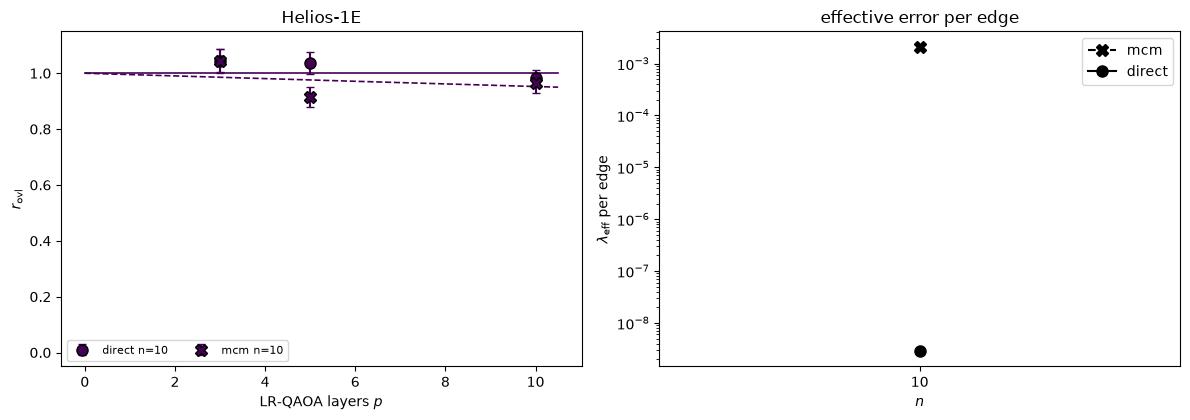


   kind    n      lambda_eff per edge    rmse
 direct   10    2.840e-09 ± 1.6e-03   0.035
    mcm   10    2.120e-03 ± 2.4e-03   0.049


In [ ]:
kappa0 = json.loads((DATA / "noise_study" / "kappa_fits.json").read_text())["kappa_0"]["value"]
runs = {kind: load_results(DATA / "results", backend.name, kind=kind, manifest_path=manifest_path) for kind in kinds}

fits = {}
print(f"kappa_0 = {kappa0:.3f}\n")
print(f"{'kind':>7} {'n':>4} {'p':>4} {'r':>7} {'r_ideal':>8} {'r_ovl':>14}")
for kind, res in runs.items():
    for chain, by_depth in sorted(res.items()):
        n = chain.n_data
        ps = np.array(sorted(by_depth), dtype=float)
        ovl = np.array([by_depth[int(p)]["r_ovl"] for p in ps])
        err = np.array([by_depth[int(p)]["r_err"] / (by_depth[int(p)]["r_ideal"] - 0.5) for p in ps])
        for p, s, e in zip(ps.astype(int), ovl, err):
            print(f"{kind:>7} {n:>4} {p:>4} {by_depth[p]['r']:>7.3f} {by_depth[p]['r_ideal']:>8.3f} {s:>8.3f} ± {e:.3f}")
        keep = ovl > 0
        if keep.sum() >= 2:
            fits[(kind, n)] = dict(ps=ps, ovl=ovl, err=err, **fit_lambda_eff(ps[keep], ovl[keep], n - 1, kappa0 / n))

fig, (ax, bx) = plt.subplots(1, 2, figsize=(12, 4.3))
cmap = plt.get_cmap("viridis")
lengths = sorted({n for _, n in fits})
colour = {n: cmap(i / max(len(lengths) - 1, 1)) for i, n in enumerate(lengths)}
grid = np.linspace(0, max(DEPTHS) * 1.05, 200)
for (kind, n), f in sorted(fits.items()):
    marker, ls = ("X", "--") if kind == "mcm" else ("o", "-")
    ax.errorbar(f["ps"], f["ovl"], yerr=f["err"], fmt=marker, color=colour[n], mec="black", ms=8, capsize=3,
                label=f"{kind} n={n}")
    ax.plot(grid, overlap_model(accumulated_error(n - 1, grid, f["lambda_eff"]), kappa0 / n), ls, color=colour[n], lw=1.2)
for kind in kinds:
    pts = sorted((n, f["lambda_eff"]) for (k, n), f in fits.items() if k == kind)
    if pts:
        bx.plot(*zip(*pts), marker="X" if kind == "mcm" else "o", ls="--" if kind == "mcm" else "-",
                color="black", mec="black", ms=8, label=kind)
ax.set(xlabel="LR-QAOA layers $p$", ylabel=r"$r_{\rm ovl}$", ylim=(-0.05, 1.15), title=backend.name)
ax.legend(fontsize=8, ncols=2)
bx.set(yscale="log", xlabel="$n$", ylabel=r"$\lambda_{\rm eff}$ per edge", xticks=lengths,
       title=r"effective error per edge")
bx.legend()
fig.tight_layout()
fig.savefig(FIGURES / f"{backend.name}_chain_lambda_eff.pdf", bbox_inches="tight")
plt.show()

print(f"\n{'kind':>7} {'n':>4} {'lambda_eff per edge':>24} {'rmse':>7}")
for (kind, n), f in sorted(fits.items()):
    print(f"{kind:>7} {n:>4} {f['lambda_eff']:>12.3e} ± {f['stderr']:.1e} {f['rmse']:>7.3f}")
if not SUBMIT:
    print("\n(local, noiseless simulation: lambda_eff should be ~0 and r_ovl ~1 within shot noise)")

## 7. Compare with the earlier Helios-1 campaign

The MCM chains of $n = 20$ (15 September 2026) and $n = 30, 40, 50$ (9 September 2026), at $p = 3, 5, 10$
and 50 shots, are stored in this repository under `data/results/Helios-1/chain/mcm/`. The 15 September run
used the parallel program of this notebook. The 9 September runs are recorded as the two-colour ordering,
but that record was not verified against the submitted programs. The same fit gives their
$\lambda_{\rm eff}$, and a new run at the same lengths should land close to them unless the machine
changed.

In [ ]:
EARLIER = {"Helios-1": ["20260915_1035", "20260909_1423", "20260909_1509", "20260909_1521"]}
earlier = load_results(DATA / "results", "Helios-1", kind="mcm",
                       files={f"{stamp}_Helios-1_chain_mcm.json" for stamp in EARLIER["Helios-1"]})
print(f"{'n':>4} {'earlier lambda_eff':>20} {'this run':>12}")
for chain, by_depth in sorted(earlier.items()):
    n = chain.n_data
    ps = np.array(sorted(by_depth), dtype=float)
    ovl = np.array([by_depth[int(p)]["r_ovl"] for p in ps])
    old = fit_lambda_eff(ps[ovl > 0], ovl[ovl > 0], n - 1, kappa0 / n)["lambda_eff"]
    new = fits.get(("mcm", n))
    print(f"{n:>4} {old:>20.3e} {new['lambda_eff'] if new else float('nan'):>12.3e}")

   n   earlier lambda_eff     this run
  20            1.168e-03          nan
  30            2.242e-03          nan
  40            3.721e-03          nan
  50            4.063e-03          nan
